# ORAS5 Compatability Analysis
## 24/11/25

In this notebook I explore the ORAS5 dataset structure with emphasis on the question: are ORAS5 and ERA5 arrays compatible?

The first key differences between ORAS5 and ERA5 are the download options:
- Consolidated or operational:
    - Consolidated = "Historical reanalysis atmospheric forcing (ERA-40 until 1978 and ERA-interim from 1979 to 2014)
        - Available from 1958 until 2014
    - Operational = "ECMWF operational atmospheric model forcing and near real time operational observation"
        - Available from 2015 to present
    - Seems to just be differences in model forcing between the two
- Single level vs all levels:
    - Single level = 2D (e.g. SST)
    - All levels = 3D (e.g. Salinity)
    - Can both be downloaded from same downloaded form
- No geospatial selection:
    - The form does not allow for a selection of just one area (e.g. covering just the UK), data for the entire globe must be downloaded! This leads to massive file sizes that exceed the built in quota (cannot download data for all years at once - multiple download forms must be submitted, possibly even one for each year)
        - 3 monthly variables for 2022 only = 16GB!

I submitted 2 download forms, one for 2022 SST only (only ~200mb) and one including salinity and rotated meridional/zonal velocities (rotated = turned from model axis to true north/south). The analysis of these datasets was done as per the following sections:

1. Dataset inspection
2. SST comparison
3. Salinity/velocity first look

## 1.0. Dataset inspection

Noteably, the simple ORAS5 dataset containing just 2022 SST exists infact as 12 datasets (1 per month) as opposed to ERA5's single dataset approach. This makes importing the data slightly more tedious, but should not have any further affect.

First I imported these 12 files and printed one off to see the general structure:

In [14]:
# Importing modules
import xarray as xr
import regionmask
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Specifying file paths
file_path_01 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202201_OPER_v0.1.nc"
file_path_02 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202202_OPER_v0.1.nc"
file_path_03 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202203_OPER_v0.1.nc"
file_path_04 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202204_OPER_v0.1.nc"
file_path_05 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202205_OPER_v0.1.nc"
file_path_06 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202206_OPER_v0.1.nc"
file_path_07 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202207_OPER_v0.1.nc"
file_path_08 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202208_OPER_v0.1.nc"
file_path_09 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202209_OPER_v0.1.nc"
file_path_10 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202210_OPER_v0.1.nc"
file_path_11 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202211_OPER_v0.1.nc"
file_path_12 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202212_OPER_v0.1.nc"

file_paths = [file_path_01, file_path_02, file_path_03, file_path_04, file_path_05, file_path_06, file_path_07, file_path_08, file_path_09, file_path_10, file_path_11, file_path_12]

# Load + concatenate along time_counter
oras5_ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='time_counter')

print(oras5_ds)

<xarray.Dataset> Size: 82MB
Dimensions:            (time_counter: 12, y: 1021, x: 1442, bnds: 2)
Coordinates:
    nav_lat            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
    nav_lon            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
  * time_counter       (time_counter) datetime64[ns] 96B 2022-01-16T12:00:00 ...
Dimensions without coordinates: y, x, bnds
Data variables:
    sosstsst           (time_counter, y, x) float32 71MB dask.array<chunksize=(1, 1021, 1442), meta=np.ndarray>
    time_counter_bnds  (time_counter, bnds) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...
    title:        Monthly mean 2D Sea Surface fields
    source:       ORAS5 - backward extension (ECMWF)
    institution:  European Centre for Medium-Range Weather Forecasts (ECMWF) ...
    reference:    https://www.ecmwf

Unfortunately the ORAS5 has dimensions time, y, x that follow a 1021 x 1442 curvilinear grid, unlike ERA5's latitutude and longitude grid. In order to merge the two we first need to regrid ORAS5 to ERA5. This is done best using xempy.

Below is the ORAS5 SST for 2022 plotted on its native tripolar curvilinear grid:

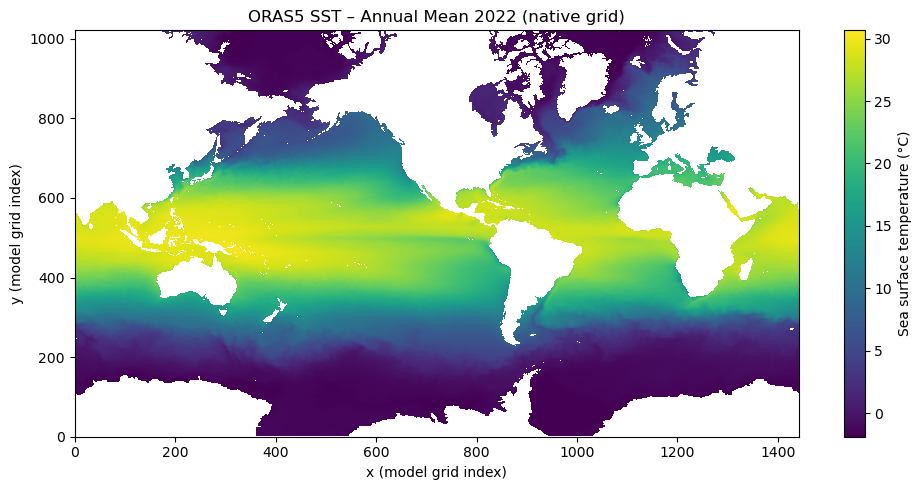

In [15]:
import matplotlib.pyplot as plt

# SST variable
sst = oras5_ds["sosstsst"]

# Annual mean
sst_annual = sst.mean(dim="time_counter")

sst_plot = sst_annual
cbar_label = "Sea surface temperature (°C)"

# Plain pcolormesh in index space
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(sst_plot, shading="auto")
plt.colorbar(im, label=cbar_label)
plt.xlabel("x (model grid index)")
plt.ylabel("y (model grid index)")
plt.title("ORAS5 SST – Annual Mean 2022 (native grid)")
plt.tight_layout()
plt.show()


I the modified the code to zoom in on the UK.

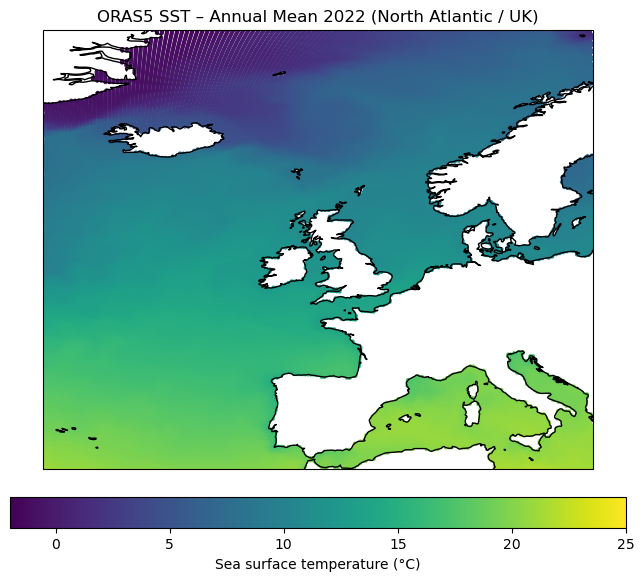

In [16]:
sst = oras5_ds["sosstsst"]
nav_lat = oras5_ds["nav_lat"]
nav_lon = oras5_ds["nav_lon"]

# Annual mean and basic masking
sst_annual = sst.mean("time_counter")
fill_val = sst.attrs.get("_FillValue", None)
if fill_val is not None:
    sst_annual = sst_annual.where(sst_annual != fill_val)

# Already in C
sst_C = sst_annual

# Flatten and keep finite values
lon = nav_lon.values.ravel()
lat = nav_lat.values.ravel()
val = sst_C.values.ravel()
valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(val)
lon, lat, val = lon[valid], lat[valid], val[valid]

# North Atlantic / UK box
region = (
    (lon >= -30) & (lon <= 20) &
    (lat >= 35)  & (lat <= 75)
)
lon, lat, val = lon[region], lat[region], val[region]

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-30, 20, 35, 75], crs=ccrs.PlateCarree())
ax.coastlines()

sc = ax.scatter(lon, lat, c=val, s=4,
                transform=ccrs.PlateCarree(),
                vmin=-2, vmax=25)

cbar = plt.colorbar(sc, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Sea surface temperature (°C)")

plt.title("ORAS5 SST – Annual Mean 2022 (North Atlantic / UK)")
plt.tight_layout()
plt.show()



Zooming in further reveals a drawback in the use of the simple scatter method. Switching to pcolormesh accounts for the corseness of data and creates a smooth plot. I also then adjusted the colourbar to represent only the values in the region selected.

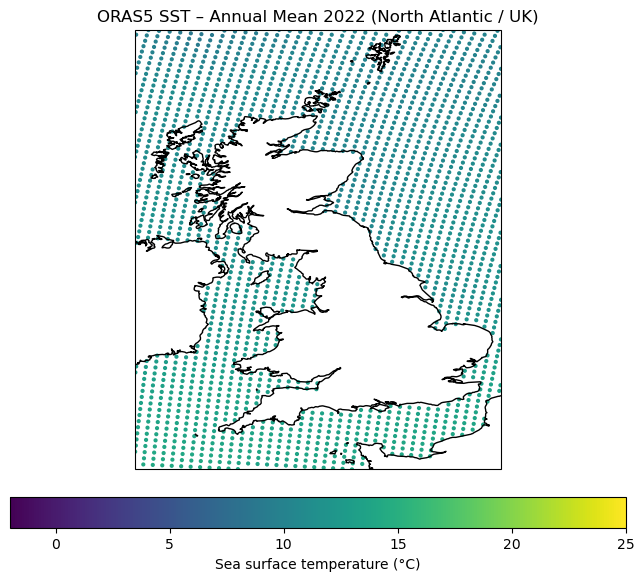

In [17]:
sst = oras5_ds["sosstsst"]
nav_lat = oras5_ds["nav_lat"]
nav_lon = oras5_ds["nav_lon"]

# UK region
lon_min = -8
lon_max = 2
lat_min = 49
lat_max = 61

# Annual mean and basic masking
sst_annual = sst.mean("time_counter")
fill_val = sst.attrs.get("_FillValue", None)
if fill_val is not None:
    sst_annual = sst_annual.where(sst_annual != fill_val)

# Aleady in C
sst_C = sst_annual

# Flatten and keep finite values
lon = nav_lon.values.ravel()
lat = nav_lat.values.ravel()
val = sst_C.values.ravel()
valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(val)
lon, lat, val = lon[valid], lat[valid], val[valid]

# North Atlantic / UK box
region = (
    (lon >= lon_min) & (lon <= lon_max) &
    (lat >= lat_min)  & (lat <= lat_max)
)
lon, lat, val = lon[region], lat[region], val[region]

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

sc = ax.scatter(lon, lat, c=val, s=4,
                transform=ccrs.PlateCarree(),
                vmin=-2, vmax=25)

cbar = plt.colorbar(sc, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Sea surface temperature (°C)")

plt.title("ORAS5 SST – Annual Mean 2022 (North Atlantic / UK)")
plt.tight_layout()
plt.show()



Region min/max SST (°C): 8.811847686767578 14.251826286315918


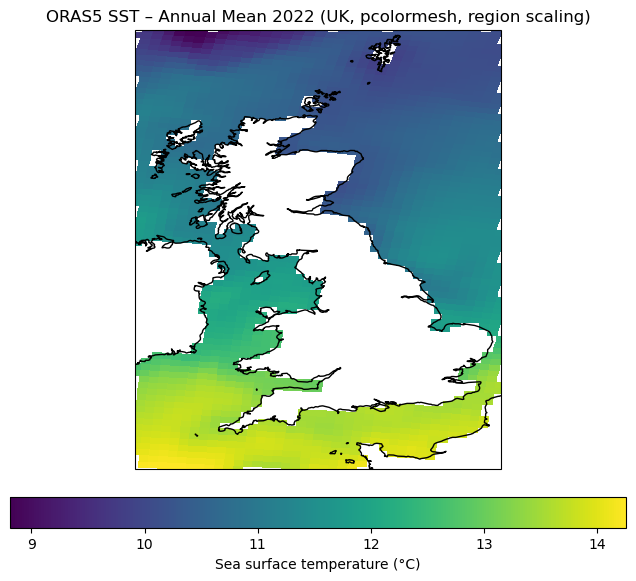

In [28]:
sst = oras5_ds["sosstsst"]
nav_lat = oras5_ds["nav_lat"]
nav_lon = oras5_ds["nav_lon"]

# UK Region
lon_min = -8
lon_max =  2
lat_min = 49
lat_max = 61

# Annual mean
sst_annual = sst.mean("time_counter")

# Mask fill values if present
fill_val = sst.attrs.get("_FillValue", None)
if fill_val is not None:
    sst_annual = sst_annual.where(sst_annual != fill_val)

# Already in C
sst_C = sst_annual

# Mask only the SST field to the UK region
region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)
sst_reg = sst_C.where(region_mask)

# Compute color limits based on actual SST values in the region
vmin = float(np.nanmin(sst_reg))
vmax = float(np.nanmax(sst_reg))

print("Region min/max SST (°C):", vmin, vmax)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    nav_lon,
    nav_lat,
    sst_reg,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Sea surface temperature (°C)")

plt.title("ORAS5 SST – Annual Mean 2022 (UK, pcolormesh, region scaling)")
plt.tight_layout()
plt.show()


## 2.0. SST Comparison

I then plotted the SST values for both the ERA5 and ORAS5 datasets side-by-side to compare. Using the same pcolormesh method we can see that the ORAS5 resolution seems to be higher than that of ERA5 (check documentation).

C:\Users\itsna\AppData\Local\Temp\ipykernel_6368\2575056916.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


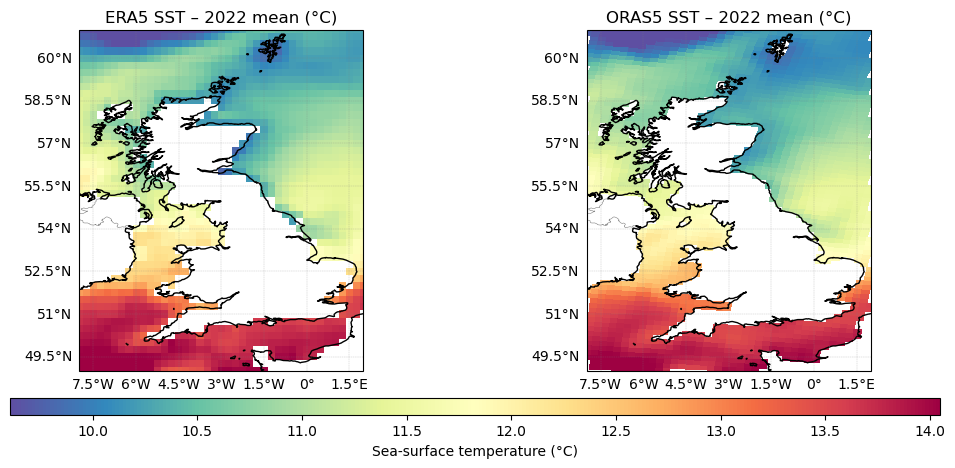

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np

file_path_b = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\data_stream-moda_stepType-avgua.nc"

colour_map = "Spectral_r"

ds = xr.open_dataset(file_path_b)

time_name = "valid_time"
lat_name  = "latitude"
lon_name  = "longitude"
sst_name  = "sst"

# Convert to C
sstK_era = ds[sst_name]
sstC_era = sstK_era - 273.15

# Time and year arrays
time_da = ds[time_name]
years   = time_da.dt.year

# 2022 mean SST
sst_2022_era = sstC_era.where(years == 2022, drop=True).mean(time_name, skipna=True)

sst_oras = oras5_ds["sosstsst"]
nav_lat  = oras5_ds["nav_lat"]
nav_lon  = oras5_ds["nav_lon"]

sst_2022_oras = (sst_oras.mean("time_counter"))

lon_min, lon_max = -8, 2
lat_min, lat_max = 49, 61

def crop_to_region(da, lon_min, lon_max, lat_min, lat_max):
    lats = da[lat_name]
    lons = da[lon_name]

    # Latitude slice
    if lats[0] < lats[-1]:
        lat_slice = slice(lat_min, lat_max)
    else:
        lat_slice = slice(lat_max, lat_min)

    # Longitude slice
    if lons[0] < lons[-1]:
        lon_slice = slice(lon_min, lon_max)
    else:
        lon_slice = slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})

# Cropping ERA5 field
sst_era_reg = crop_to_region(sst_2022_era, lon_min, lon_max, lat_min, lat_max)

# Crop ORAS5 field via mask on 2D lat/lon
oras_region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)
sst_oras_reg = sst_2022_oras.where(oras_region_mask)

#Shared colour bar
stack = np.concatenate([
    sst_era_reg.values.ravel(),
    sst_oras_reg.values.ravel()
])
vmin = np.nanpercentile(stack, 2)
vmax = np.nanpercentile(stack, 98)
levels = np.linspace(vmin, vmax, 21)

# lon/lat for ERA5 plotting
lon_reg_era = sst_era_reg[lon_name]
lat_reg_era = sst_era_reg[lat_name]

proj = ccrs.PlateCarree()

# Plotting
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[20, 1], hspace=0.15)

ax_era  = fig.add_subplot(gs[0, 0], projection=proj)
ax_oras = fig.add_subplot(gs[0, 1], projection=proj)
cax     = fig.add_subplot(gs[1, :])

for ax in [ax_era, ax_oras]:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.coastlines(resolution="10m", color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="gray")

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        linestyle="--",
        color="gray",
        alpha=0.5,
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False
    gl.right_labels = False

# ERA5 reg grid
cs_era = ax_era.pcolormesh(
    lon_reg_era, lat_reg_era, sst_era_reg,
    cmap=colour_map, vmin=vmin, vmax=vmax,
    transform=proj, shading="auto"
)
ax_era.set_title("ERA5 SST – 2022 mean (°C)")

# ORAS5 curvilinear grid
cs_oras = ax_oras.pcolormesh(
    nav_lon, nav_lat, sst_oras_reg,
    transform=proj,
    cmap=colour_map, vmin=vmin, vmax=vmax,
    shading="auto"
)
ax_oras.set_title("ORAS5 SST – 2022 mean (°C)")

# Colourbar
cbar = fig.colorbar(cs_oras, cax=cax, orientation="horizontal")
cbar.set_label("Sea-surface temperature (°C)")

plt.tight_layout()
plt.show()


## 3.0. Salininty/Velocity

I then chose some interesting ORAS5 variables to explore. Due to the large file sizes I only chose 3 (salinity, zonal velocity and meridional velocity) and could only cover one year of data (2022). Each variable once again came in the form of 12 files (one per month) for 2022.

In [20]:
import xarray as xr

# Salinity files
file_path_sal_01 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202201_OPER_v0.1.nc"
file_path_sal_02 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202202_OPER_v0.1.nc"
file_path_sal_03 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202203_OPER_v0.1.nc"
file_path_sal_04 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202204_OPER_v0.1.nc"
file_path_sal_05 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202205_OPER_v0.1.nc"
file_path_sal_06 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202206_OPER_v0.1.nc"
file_path_sal_07 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202207_OPER_v0.1.nc"
file_path_sal_08 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202208_OPER_v0.1.nc"
file_path_sal_09 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202209_OPER_v0.1.nc"
file_path_sal_10 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202210_OPER_v0.1.nc"
file_path_sal_11 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202211_OPER_v0.1.nc"
file_path_sal_12 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vosaline_control_monthly_highres_3D_202212_OPER_v0.1.nc"

sal_files = [
    file_path_sal_01, file_path_sal_02, file_path_sal_03, file_path_sal_04,
    file_path_sal_05, file_path_sal_06, file_path_sal_07, file_path_sal_08,
    file_path_sal_09, file_path_sal_10, file_path_sal_11, file_path_sal_12,
]

sal_ds = xr.open_mfdataset(sal_files, combine="by_coords")


# Zonal veloc files
file_path_u_01 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202201_OPER_v0.1.nc"
file_path_u_02 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202202_OPER_v0.1.nc"
file_path_u_03 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202203_OPER_v0.1.nc"
file_path_u_04 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202204_OPER_v0.1.nc"
file_path_u_05 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202205_OPER_v0.1.nc"
file_path_u_06 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202206_OPER_v0.1.nc"
file_path_u_07 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202207_OPER_v0.1.nc"
file_path_u_08 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202208_OPER_v0.1.nc"
file_path_u_09 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202209_OPER_v0.1.nc"
file_path_u_10 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202210_OPER_v0.1.nc"
file_path_u_11 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202211_OPER_v0.1.nc"
file_path_u_12 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vozocrte_control_monthly_highres_3D_202212_OPER_v0.1.nc"

u_files = [
    file_path_u_01, file_path_u_02, file_path_u_03, file_path_u_04,
    file_path_u_05, file_path_u_06, file_path_u_07, file_path_u_08,
    file_path_u_09, file_path_u_10, file_path_u_11, file_path_u_12,
]

u_ds = xr.open_mfdataset(u_files, combine="by_coords")


# Meridional veloc files
file_path_v_01 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202201_OPER_v0.1.nc"
file_path_v_02 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202202_OPER_v0.1.nc"
file_path_v_03 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202203_OPER_v0.1.nc"
file_path_v_04 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202204_OPER_v0.1.nc"
file_path_v_05 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202205_OPER_v0.1.nc"
file_path_v_06 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202206_OPER_v0.1.nc"
file_path_v_07 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202207_OPER_v0.1.nc"
file_path_v_08 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202208_OPER_v0.1.nc"
file_path_v_09 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202209_OPER_v0.1.nc"
file_path_v_10 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202210_OPER_v0.1.nc"
file_path_v_11 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202211_OPER_v0.1.nc"
file_path_v_12 = r"C:\Users\itsna\OneDrive\Desktop\MSc Work\DataSets\ORAS5\Salinity, Velocity\vomecrtn_control_monthly_highres_3D_202212_OPER_v0.1.nc"

v_files = [
    file_path_v_01, file_path_v_02, file_path_v_03, file_path_v_04,
    file_path_v_05, file_path_v_06, file_path_v_07, file_path_v_08,
    file_path_v_09, file_path_v_10, file_path_v_11, file_path_v_12,
]

v_ds = xr.open_mfdataset(v_files, combine="by_coords")

# Prints
print("Salinity dataset:", sal_ds)
print("Zonal velocity dataset:", u_ds)
print("Meridional velocity dataset:", v_ds)


Salinity dataset: <xarray.Dataset> Size: 5GB
Dimensions:            (time_counter: 12, bnds: 2, deptht: 75, y: 1021, x: 1442)
Coordinates:
  * deptht             (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
    nav_lon            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
  * time_counter       (time_counter) datetime64[ns] 96B 2022-01-16T12:00:00 ...
Dimensions without coordinates: bnds, y, x
Data variables:
    time_counter_bnds  (time_counter, bnds) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
    vosaline           (time_counter, deptht, y, x) float32 5GB dask.array<chunksize=(1, 19, 341, 481), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...
    title:        Monthly mean salinity
    source:       ORAS5 - backward extension (ECMWF)
    institution:  E

With the datasets loaded, I then plotted salinity over the whole region:

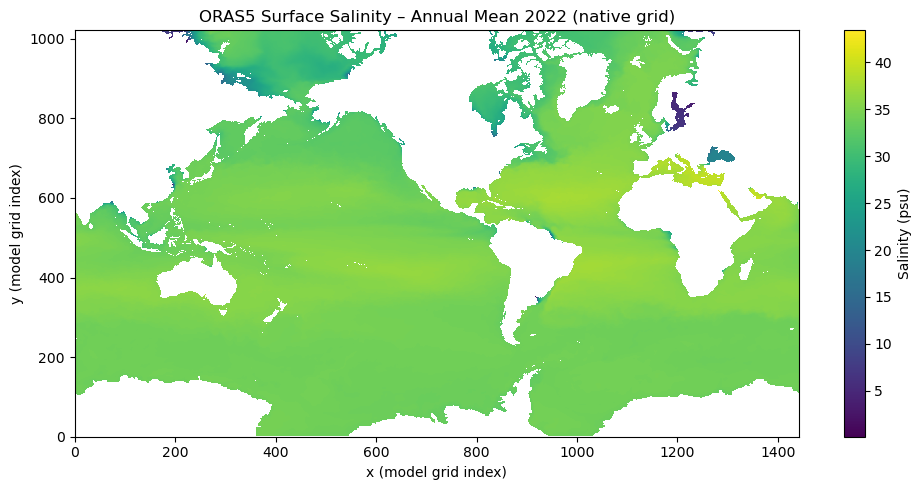

In [21]:
import matplotlib.pyplot as plt

# Salinity var
sal = sal_ds["vosaline"]

# Surface level and annual mean
sal_surface = sal.isel(deptht=0)
sal_annual  = sal_surface.mean(dim="time_counter")

# Plot on native (y, x) grid
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(sal_annual, shading="auto")
plt.colorbar(im, label="Salinity (psu)")
plt.xlabel("x (model grid index)")
plt.ylabel("y (model grid index)")
plt.title("ORAS5 Surface Salinity – Annual Mean 2022 (native grid)")
plt.tight_layout()
plt.show()


On this scale the image looks flat. Zooming in on areas with freshwater melting and runoff could offer more interesting images. First I zoomed in on the UK:

Region min/max salinity (psu): 31.3824520111084 35.28348159790039


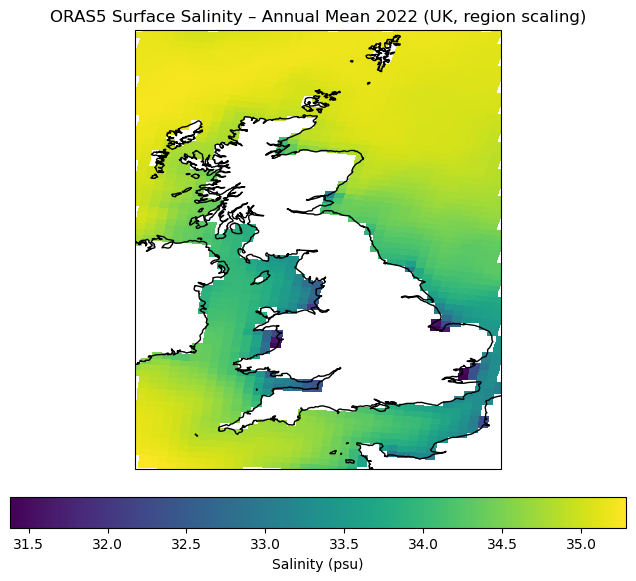

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

sal     = sal_ds["vosaline"]
nav_lat = sal_ds["nav_lat"]
nav_lon = sal_ds["nav_lon"]

lon_min = -8
lon_max =  2
lat_min = 49
lat_max = 61

# Surface level and annual mean
sal_surface = sal.isel(deptht=0)
sal_annual  = sal_surface.mean("time_counter")

# Masking the salinity to UK region
region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)
sal_reg = sal_annual.where(region_mask)

# Getting colour limmits from region
vmin = float(np.nanmin(sal_reg))
vmax = float(np.nanmax(sal_reg))

print("Region min/max salinity (psu):", vmin, vmax)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    nav_lon,
    nav_lat,
    sal_reg,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Salinity (psu)")

plt.title("ORAS5 Surface Salinity – Annual Mean 2022 (UK, region scaling)")
plt.tight_layout()
plt.show()


The darker areas of lower a salinity around the UK are likely due to rivers, rainfall, runoff etc. I then zoomed in on the North Atlantic area:

Region min/max salinity (psu): 12.698487281799316 38.15501022338867


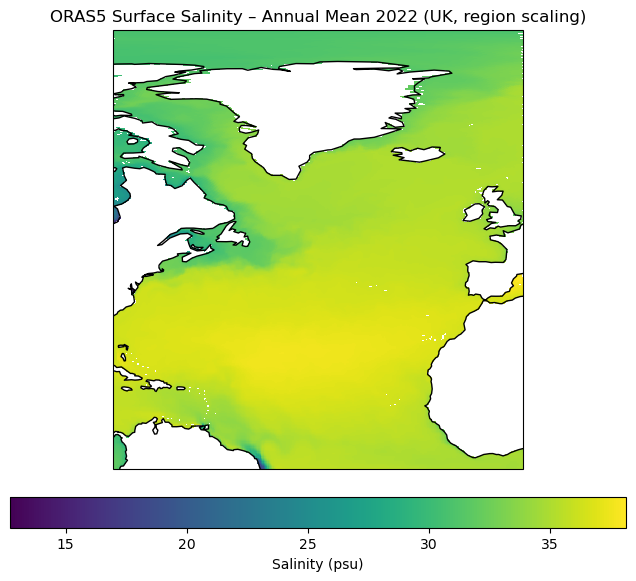

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

sal     = sal_ds["vosaline"]
nav_lat = sal_ds["nav_lat"]
nav_lon = sal_ds["nav_lon"]

lon_min = -80
lon_max =  2
lat_min = 2
lat_max = 90

# Surface level and annual mean
sal_surface = sal.isel(deptht=0)
sal_annual  = sal_surface.mean("time_counter")

# Masing salinity to UK
region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)
sal_reg = sal_annual.where(region_mask)

# Getting colour limits from region
vmin = float(np.nanmin(sal_reg))
vmax = float(np.nanmax(sal_reg))

print("Region min/max salinity (psu):", vmin, vmax)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    nav_lon,
    nav_lat,
    sal_reg,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Salinity (psu)")

plt.title("ORAS5 Surface Salinity – Annual Mean 2022 (UK, region scaling)")
plt.tight_layout()
plt.show()


The area around greenland is lighter than expected. To counteract this I zoomed in on Greenland and plotted only the Summer season (JJA) salinity:

Region min/max salinity (psu): 18.771657943725586 35.37355041503906


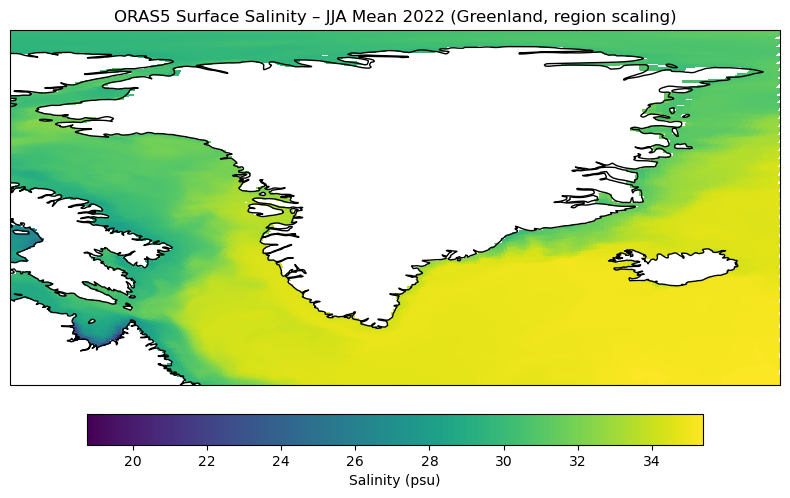

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

sal     = sal_ds["vosaline"]
nav_lat = sal_ds["nav_lat"]
nav_lon = sal_ds["nav_lon"]

lon_min = -75
lon_max = -10
lat_min =  55
lat_max =  85

sal_surface = sal.isel(deptht=0)

# JJA selection
months = sal_ds["time_counter"].dt.month
jja_mask = (months >= 6) & (months <= 8)

sal_jja = sal_surface.sel(time_counter=jja_mask).mean("time_counter")

# Masking sal to region
region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)
sal_reg = sal_jja.where(region_mask)

# Getting colour limits from region
vmin = float(np.nanmin(sal_reg))
vmax = float(np.nanmax(sal_reg))

print("Region min/max salinity (psu):", vmin, vmax)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    nav_lon,
    nav_lat,
    sal_reg,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Salinity (psu)")

plt.title("ORAS5 Surface Salinity – JJA Mean 2022 (Greenland, region scaling)")
plt.tight_layout()
plt.show()


This helps highlight the freshwater introduced to the atlantic from Greenland snow/ice melt.

I then moved on to the zonal and meridional velocity datasets, initially just plotting each:

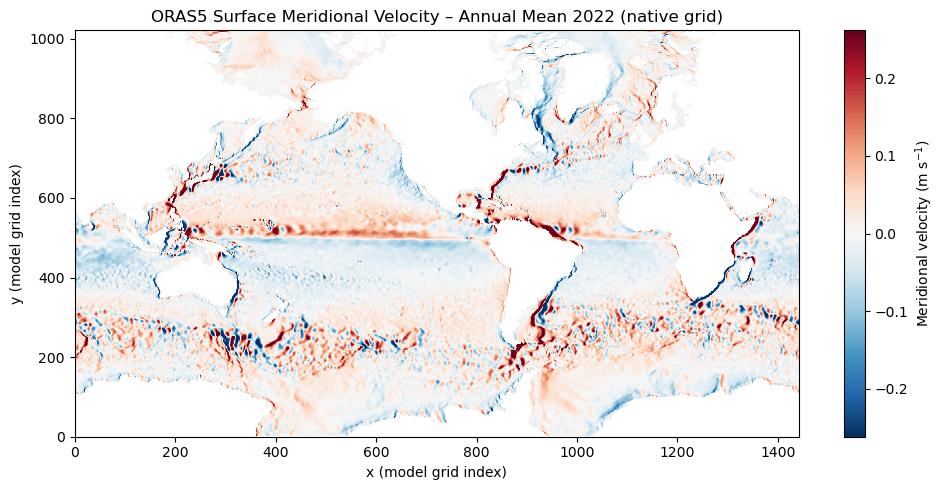

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Meridional velocity
v = v_ds["vomecrtn"]

# Surface level and annual mean
v_surface = v.isel(deptht=0)
v_annual  = v_surface.mean(dim="time_counter")

# Symmetric colour map
vmax = float(np.nanpercentile(np.abs(v_annual), 99))
vmin = -vmax

# Plotting
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(v_annual, shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
plt.colorbar(im, label="Meridional velocity (m s$^{-1}$)")
plt.xlabel("x (model grid index)")
plt.ylabel("y (model grid index)")
plt.title("ORAS5 Surface Meridional Velocity – Annual Mean 2022 (native grid)")
plt.tight_layout()
plt.show()


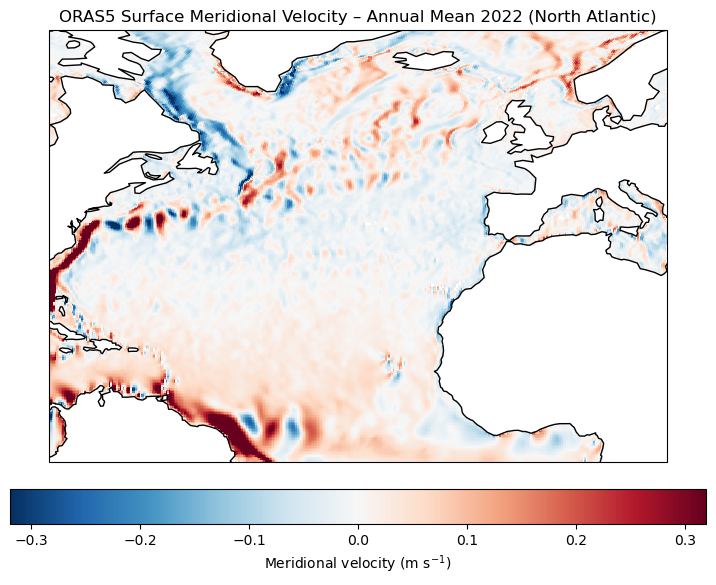

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

# Meridional velocity variable
v = v_ds["vomecrtn"]
nav_lat = v_ds["nav_lat"]
nav_lon = v_ds["nav_lon"]

# Select surface level and annual mean
v_surface = v.isel(deptht=0)
v_annual = v_surface.mean(dim="time_counter")

# Atlantic region
lon_min, lon_max = -80, 20
lat_min, lat_max = 0, 70

# Masking to the region
region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

v_reg = v_annual.where(region_mask)

# Symmetric colour map
vmax = float(np.nanpercentile(np.abs(v_reg), 99))
vmin = -vmax

# Plotting
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    nav_lon,
    nav_lat,
    v_reg,
    shading="auto",
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Meridional velocity (m s$^{-1}$)")

plt.title("ORAS5 Surface Meridional Velocity – Annual Mean 2022 (North Atlantic)")
plt.tight_layout()
plt.show()


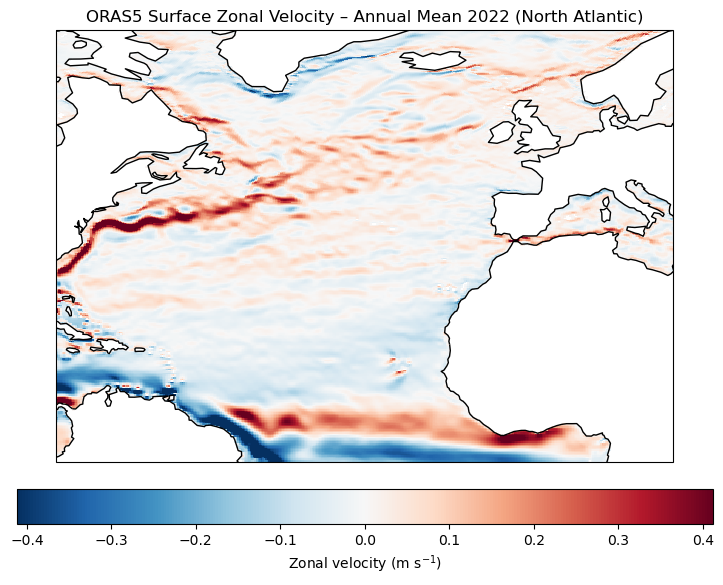

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

# Zonal velocity variable
u = u_ds["vozocrte"]
nav_lat = u_ds["nav_lat"]
nav_lon = u_ds["nav_lon"]

# Surface level + annual mean
u_surface = u.isel(deptht=0)
u_annual = u_surface.mean(dim="time_counter")

# Atlantic region
lon_min, lon_max = -80, 20
lat_min, lat_max = 0, 70

# Mask to region
region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

u_reg = u_annual.where(region_mask)

# Symmetric colour map
umax = float(np.nanpercentile(np.abs(u_reg), 99))
umin = -umax

# Plot
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    nav_lon,
    nav_lat,
    u_reg,
    shading="auto",
    cmap="RdBu_r",
    vmin=umin,
    vmax=umax,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Zonal velocity (m s$^{-1}$)")

plt.title("ORAS5 Surface Zonal Velocity – Annual Mean 2022 (North Atlantic)")
plt.tight_layout()
plt.show()


The seperate zonal and meridional plots aren't massively intuitive so I consulted ChatGPT who combined the two datasets into one plot. This plots speed with colour and direction with vector arrows.

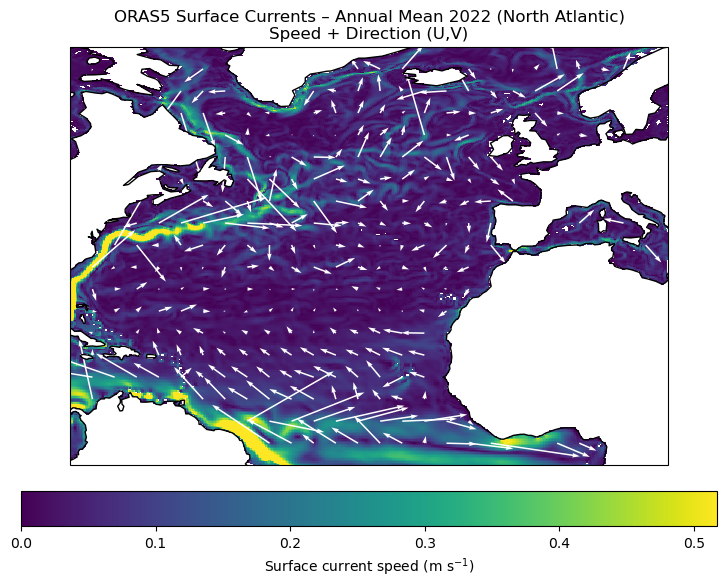

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Load fields from your datasets ---
u = u_ds["vozocrte"]    # (time_counter, deptht, y, x)
v = v_ds["vomecrtn"]
nav_lat = u_ds["nav_lat"]
nav_lon = u_ds["nav_lon"]

# --- Surface + annual mean ---
u_sfc = u.isel(deptht=0).mean("time_counter")
v_sfc = v.isel(deptht=0).mean("time_counter")

# --- Region: North Atlantic ---
lon_min, lon_max = -80, 20
lat_min, lat_max = 0, 70

region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

u_reg = u_sfc.where(region_mask)
v_reg = v_sfc.where(region_mask)

# --- Speed (for colour background) ---
speed = np.hypot(u_reg, v_reg)

# Colour scale for speed
smax = float(np.nanpercentile(speed, 99))
smin = 0.0

# --- Subsample for arrows so the plot isn't crazy dense ---
step = 8   # increase if still too busy
lon_q = nav_lon[::step, ::step]
lat_q = nav_lat[::step, ::step]
u_q   = u_reg[::step, ::step]
v_q   = v_reg[::step, ::step]

# --- Plot ---
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

# Background: speed
pm = ax.pcolormesh(
    nav_lon, nav_lat, speed,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=smin, vmax=smax
)

# Vectors: U + V
q = ax.quiver(
    lon_q, lat_q, u_q, v_q,
    transform=ccrs.PlateCarree(),
    scale=2.0,           # tweak for arrow size
    regrid_shape=20,      # optional additional thinning
    color="white"
)

# Colourbar
cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Surface current speed (m s$^{-1}$)")

plt.title("ORAS5 Surface Currents – Annual Mean 2022 (North Atlantic)\nSpeed + Direction (U,V)")
plt.tight_layout()
plt.show()


The above plot covers only surface values. I then tried plotting the velocities at depth (2000m):

Using model depth level 53 at depth ≈ 1945.3 m


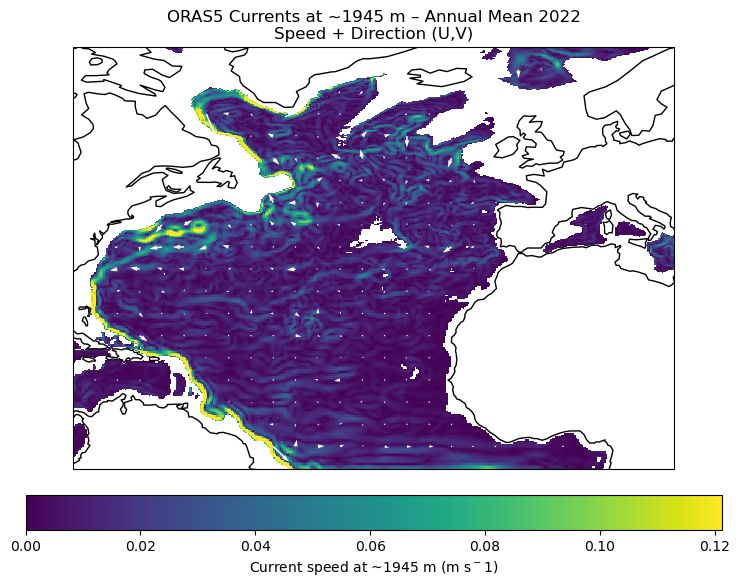

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Load fields ---
u = u_ds["vozocrte"]    # (time_counter, deptht, y, x)
v = v_ds["vomecrtn"]
nav_lat = u_ds["nav_lat"]
nav_lon = u_ds["nav_lon"]
depths = u_ds["deptht"]     # depth coordinate

# === Choose depth level (meters) ===
target_depth = 2000.0

# Find nearest depth index
depth_idx = int(np.argmin(np.abs(depths.values - target_depth)))
print(f"Using model depth level {depth_idx} at depth ≈ {depths.values[depth_idx]:.1f} m")

# --- Annual mean at this depth ---
u_d = u.isel(deptht=depth_idx).mean("time_counter")
v_d = v.isel(deptht=depth_idx).mean("time_counter")

# --- Region: North Atlantic ---
lon_min, lon_max = -80, 20
lat_min, lat_max = 0, 70

region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

u_reg = u_d.where(region_mask)
v_reg = v_d.where(region_mask)

# --- Speed (for colour background) ---
speed = np.hypot(u_reg, v_reg)
smax = float(np.nanpercentile(speed, 99))
smin = 0.0

# --- Subsample for arrows ---
step = 8
lon_q = nav_lon[::step, ::step]
lat_q = nav_lat[::step, ::step]
u_q   = u_reg[::step, ::step]
v_q   = v_reg[::step, ::step]

# --- Plot ---
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

# Background: speed
pm = ax.pcolormesh(
    nav_lon, nav_lat, speed,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=smin, vmax=smax
)

# Arrows
q = ax.quiver(
    lon_q, lat_q, u_q, v_q,
    transform=ccrs.PlateCarree(),
    scale=2.0,
    regrid_shape=20,
    color="white"
)

# Colourbar
cbar = plt.colorbar(pm, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label(f"Current speed at ~{depths.values[depth_idx]:.0f} m (m s$^{-1}$)")

plt.title(f"ORAS5 Currents at ~{depths.values[depth_idx]:.0f} m – Annual Mean 2022\nSpeed + Direction (U,V)")
plt.tight_layout()
plt.show()


I then attempted to plot a slice of the data (longitude vs depth):

Using y=608 at latitude 26.47°


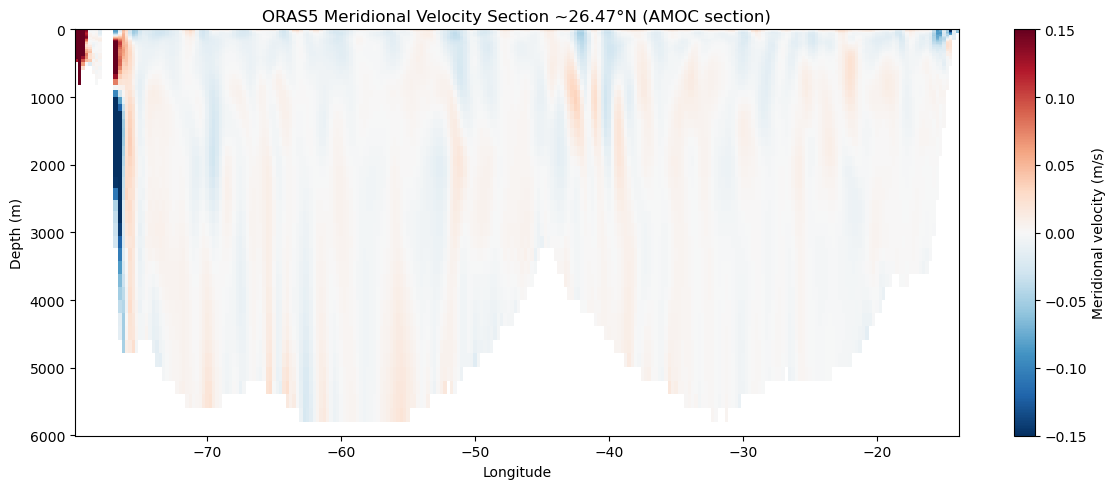

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Shortcuts
v       = v_ds["vomecrtn"]
sal     = sal_ds["vosaline"]
nav_lat = v_ds["nav_lat"]
nav_lon = v_ds["nav_lon"]
depth   = v_ds["deptht"]

# Finding the laitiude closest to 26 deg north
lat_target = 26.5
lat_mean = nav_lat.mean(dim="x")
y_idx = int(np.abs(lat_mean - lat_target).argmin())

print(f"Using y={y_idx} at latitude {float(lat_mean.isel(y=y_idx)):.2f}°")

# Slicing fields along that row
v_line   = v.isel(y=y_idx)
sal_line = sal.isel(y=y_idx)
lon_line = nav_lon.isel(y=y_idx)

# Annual means
v_mean   = v_line.mean("time_counter")
sal_mean = sal_line.mean("time_counter")

# USing previous salinity mask to keep only atlantic area
atl_mask = (
    (lon_line >= -80) & (lon_line <= 20) &
    np.isfinite(sal_mean.isel(deptht=0))
)

x_idx = np.where(atl_mask.values)[0]

v_mean   = v_mean.isel(x=x_idx)
lon_line = lon_line.isel(x=x_idx)

# Masking land
v_masked = v_mean.where(np.isfinite(sal_mean.isel(x=x_idx)))

# Plotting
plt.figure(figsize=(12, 5))

cs = plt.pcolormesh(
    lon_line,
    depth,
    v_masked,
    cmap="RdBu_r",
    shading="auto",
    vmin=-0.15, vmax=0.15
)

plt.gca().invert_yaxis()
plt.colorbar(cs, label="Meridional velocity (m/s)")
plt.xlabel("Longitude")
plt.ylabel("Depth (m)")
plt.title(f"ORAS5 Meridional Velocity Section ~{float(lat_mean.isel(y=y_idx)):.2f}°N (AMOC section)")

plt.tight_layout()
plt.show()


In another attempt to visualise some "overturning" properties, I then plotted only the meridional velocities at the surface and at  2000m depth side by side:

Deep level ≈ 1945.3 m (index 53)


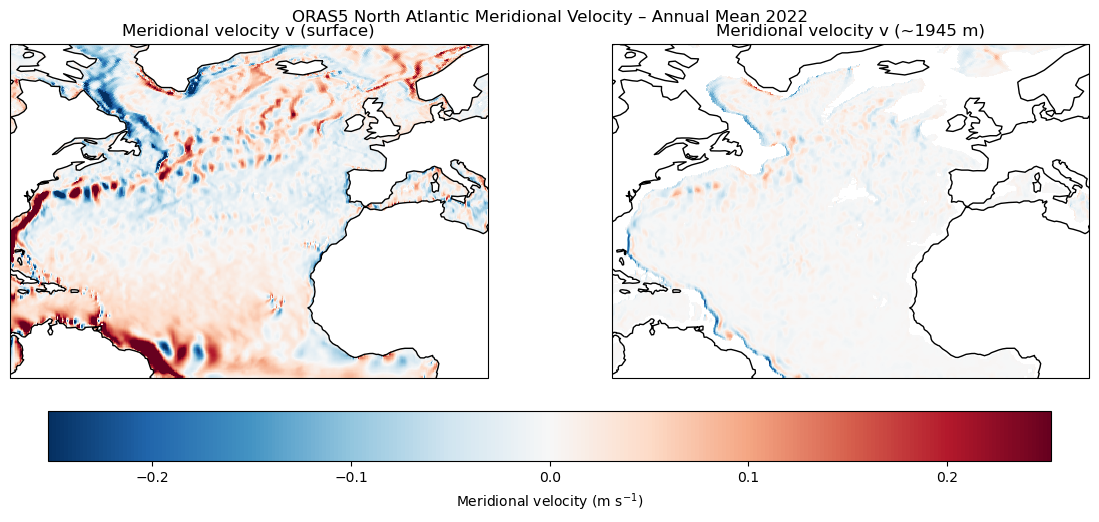

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

v = v_ds["vomecrtn"]
nav_lat = v_ds["nav_lat"]
nav_lon = v_ds["nav_lon"]
depths = v_ds["deptht"]

# Choosing depth closest to 2000m
target_depth = 2000.0
deep_idx = int(np.argmin(np.abs(depths.values - target_depth)))
print(f"Deep level ≈ {depths.values[deep_idx]:.1f} m (index {deep_idx})")

# Time avg at surface and depth
v_sfc  = v.isel(deptht=0).mean("time_counter")
v_deep = v.isel(deptht=deep_idx).mean("time_counter")

# North atlantic region
lon_min, lon_max = -80, 20
lat_min, lat_max = 0, 70

region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

v_sfc_reg  = v_sfc.where(region_mask)
v_deep_reg = v_deep.where(region_mask)

# shared symmetric colour limits
stack = np.concatenate([
    v_sfc_reg.values.ravel(),
    v_deep_reg.values.ravel()
])
vmax = np.nanpercentile(np.abs(stack), 99)
vmin = -vmax

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

for ax in axes:
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
    ax.coastlines()

im0 = axes[0].pcolormesh(
    nav_lon, nav_lat, v_sfc_reg,
    transform=proj, cmap="RdBu_r",
    vmin=vmin, vmax=vmax, shading="auto"
)
axes[0].set_title("Meridional velocity v (surface)")

im1 = axes[1].pcolormesh(
    nav_lon, nav_lat, v_deep_reg,
    transform=proj, cmap="RdBu_r",
    vmin=vmin, vmax=vmax, shading="auto"
)
axes[1].set_title(f"Meridional velocity v (~{depths.values[deep_idx]:.0f} m)")

cbar = fig.colorbar(im1, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label("Meridional velocity (m s$^{-1}$)")

plt.suptitle("ORAS5 North Atlantic Meridional Velocity – Annual Mean 2022", y=1.02)
plt.show()
